BTP Project @2025

In [1]:
!unzip -q /content/NMS.zip

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

# === 1. DEFINE CONSTANTS ===

# Update this path to where you unzipped your data
DATA_DIR = 'data'
IMAGE_SIZE = (224, 224)  # Standard size for EfficientNetB0
BATCH_SIZE = 32
EPOCHS = 20 # Start with 20 and see how it goes
NUM_CLASSES = 3 # severe, moderate, normal

# === 2. LOAD YOUR DATA ===
# This function is a lifesaver. It automatically finds your class folders
# and labels them (e.g., 0=moderate, 1=normal, 2=severe).

# Create a training dataset (80% of the data)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,  # 20% of data will be for validation
    subset="training",
    seed=123,  # Seed ensures training and validation sets don't overlap
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int' # For 'sparse_categorical_crossentropy'
)

# Create a validation dataset (the other 20%)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# Get the class names (it will be ['moderate', 'normal', 'severe'] alphabetically)
class_names = train_dataset.class_names
print(f"Found class names: {class_names}")

# === 3. CREATE DATA AUGMENTATION LAYER ===
# This creates new variations of your images (flips, rotations)
# during training to make your model more robust.
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# === 4. BUILD THE MODEL (TRANSFER LEARNING) ===

# Load EfficientNetB0 pre-trained on ImageNet
# include_top=False means we're chopping off its final prediction layer
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=IMAGE_SIZE + (3,), # (224, 224, 3)
    pooling='avg' # Applies Global Average Pooling
)

# Freeze the base model (we don't want to re-train all of its weights)
base_model.trainable = False

# Build our new model
inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,), name="input_layer")

# 1. Augment the data (only happens during training)
x = data_augmentation(inputs)

# 2. Rescale pixels from [0, 255] to [0, 1], which EfficientNet expects
# (This is built into the EfficientNet model, but good to be aware)
# We call the base model, setting training=False so it runs in inference mode
x = base_model(x, training=False)

# 3. Add a Dropout layer to prevent overfitting
x = tf.keras.layers.Dropout(0.2, name="dropout_layer")(x)

# 4. Add our final prediction layer
# It's a Dense layer with NUM_CLASSES units and 'softmax' activation
# Softmax will give us the probability for each class
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name="output_layer")(x)

# Create the final model
model = tf.keras.Model(inputs, outputs)

# === 5. COMPILE THE MODEL ===
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    # Use 'sparse' because our labels are simple integers (0, 1, 2)
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Let's see our model architecture
model.summary()

# === 6. TRAIN THE MODEL! ===
print("\nStarting training...")
history = model.fit(
    train_dataset,
     validation_data=validation_dataset,
    epochs=EPOCHS
)
# Define the save path in your Google Drive
SAVE_PATH = '/content/drive/MyDrive/rutting_classifier.h5'
# Save the entire model to a single HDF5 file.
model.save(SAVE_PATH)

print(f"Model saved to your Google Drive at: {SAVE_PATH}")
print("Training finished!")

Found 2620 files belonging to 3 classes.
Using 2096 files for training.
Found 2620 files belonging to 3 classes.
Using 524 files for validation.
Found class names: ['moderate', 'normal', 'severe']
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


Starting training...
Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.5863 - loss: 0.9125 - val_accuracy: 0.7137 - val_loss: 0.6740
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.7262 - loss: 0.6671 - val_accuracy: 0.7290 - val_loss: 0.6217
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 268s 3s/step - accuracy: 0.7337 - loss: 0.6148 - val_accuracy: 0.7405 - val_loss: 0.5983
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.7434 - loss: 0.5939 - val_accuracy: 0.7405 - val_loss: 0.5926
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 273s 3s/step - accuracy: 0.7637 - loss: 0.5833 - val_accuracy: 0.7443 - val_loss: 0.5805
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.7703 - loss: 0.5575 - val_accuracy: 0.7481 - val_loss: 0.5769
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - accuracy: 0.7460 - loss: 0.5945 - val_accuracy: 0.7462 - val_loss: 0.5668
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 219s 3s/step - accuracy: 0.7651 - loss: 0.5306 - va

Model saved to your Google Drive at: /content/drive/MyDrive/rutting_classifier.h5
Training finished!


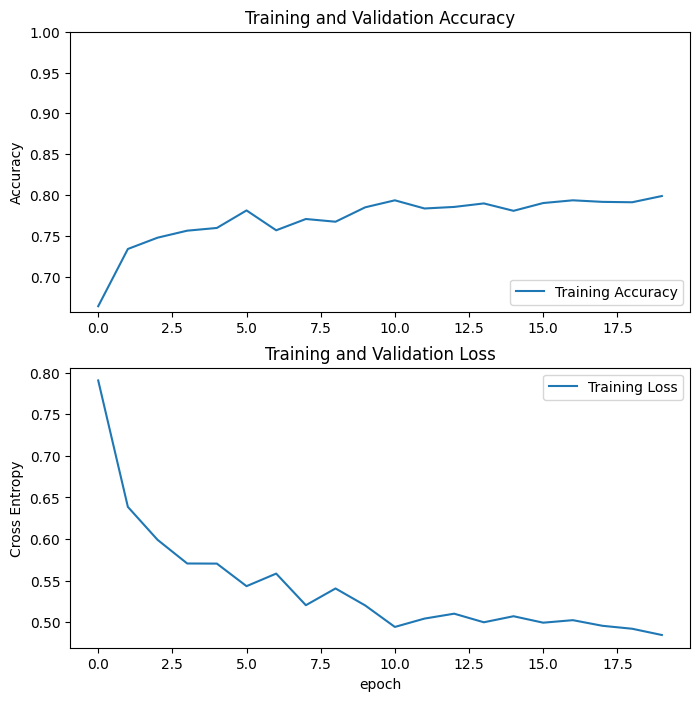


Generating Confusion Matrix...
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


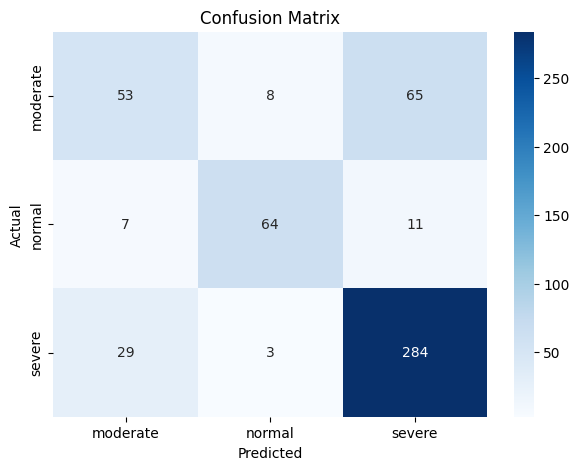


Classification Report:
              precision    recall  f1-score   support

    moderate       0.60      0.42      0.49       126
      normal       0.85      0.78      0.82        82
      severe       0.79      0.90      0.84       316

    accuracy                           0.77       524
   macro avg       0.75      0.70      0.72       524
weighted avg       0.75      0.77      0.75       524



In [4]:
# === 7. PLOT ACCURACY AND LOSS ===
acc = history.history['accuracy']
# val_acc = history.history['validation_accuracy']
loss = history.history['loss']
# val_loss = history.history['validation_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
# plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
# plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()


# === 8. GENERATE A CONFUSION MATRIX ===
# This is the most important part!
print("\nGenerating Confusion Matrix...")
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get all labels and predictions from the validation set
y_true = []
y_pred_probs = []

for images, labels in validation_dataset:
    y_true.extend(labels.numpy())
    y_pred_probs.extend(model.predict(images))

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print a classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))